# Overall Findings

### 1. Age: customers aged 31-70 spend more money overall, but less likely to accept campaigns.
### 2. Customers purchasing through catalogs are more likely to accept campaigns. In-person customers spend more. 
    ### Recommended split: 40% catalog, 30% in-store, 30% web
### 3. Focus on customers with fewer or no kids
### 4. Education status has no impact
### 5. Marital Status: Married, Single, and Together spend more 


# Reccomendations: 
1. Focus marketing on middle-aged customers, high earners, with no kids. Target on different platfroms with splits in #2.
2. Focus marketing on age groups that accept campaigns at higher rates (21-30 & 70+)

In [2]:
import pandas as pd

In [3]:
food = pd.read_csv(r'C:\Users\deang\Documents\Python tutorials\U Food Data Analysis\u_food_marketing.csv')
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [5]:
pd.set_option('display.max.columns',50)
pd.set_option('display.max.rows',2300)
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0


In [29]:
food.drop_duplicates(keep = False,inplace = True)
food.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1843 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                1843 non-null   float64
 1   Kidhome               1843 non-null   int64  
 2   Teenhome              1843 non-null   int64  
 3   Recency               1843 non-null   int64  
 4   MntWines              1843 non-null   int64  
 5   MntFruits             1843 non-null   int64  
 6   MntMeatProducts       1843 non-null   int64  
 7   MntFishProducts       1843 non-null   int64  
 8   MntSweetProducts      1843 non-null   int64  
 9   MntGoldProds          1843 non-null   int64  
 10  NumDealsPurchases     1843 non-null   int64  
 11  NumWebPurchases       1843 non-null   int64  
 12  NumCatalogPurchases   1843 non-null   int64  
 13  NumStorePurchases     1843 non-null   int64  
 14  NumWebVisitsMonth     1843 non-null   int64  
 15  AcceptedCmp3          1843

In [30]:
food['Total_Children'] = food[['Kidhome','Teenhome']].sum(axis = 1)

In [31]:
food['marital_Divorced'] = food['marital_Divorced'].replace({1:5,0:0})
food['marital_Married'] = food['marital_Married'].replace({1:4,0:0})
food['marital_Single'] = food['marital_Single'].replace({1:3,0:0})
food['marital_Together'] = food['marital_Together'].replace({1:2,0:0})
food['marital_Widow'] = food['marital_Widow'].replace({1:1,0:0})

In [32]:
food['Marital_Status'] = food[['marital_Divorced','marital_Married','marital_Single','marital_Together','marital_Widow']].sum(axis=1)

In [35]:
food['Marital_Status_str'] = food['Marital_Status'].map({5:'Divorced', 4:'married', 3:'Single', 2:'Together', 1:'Widow'})

In [38]:
food['education_2n Cycle'] = food['education_2n Cycle'].replace({1:1,0:0})
food['education_Basic'] = food['education_Basic'].replace({1:2,0:0})
food['education_Graduation'] = food['education_Graduation'].replace({1:3,0:0})
food['education_Master'] = food['education_Master'].replace({1:4,0:0})
food['education_PhD'] = food['education_PhD'].replace({1:5,0:0})

In [39]:
food['Education_Status'] = food[['education_2n Cycle','education_Basic','marital_Single','education_Graduation','education_Master','education_PhD']].sum(axis=1)

In [61]:
food['Accepted_Campaigns'] = food[['AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp2','AcceptedCmp1','Response']].sum(axis=1)

In [62]:
food['Accepted_Campaigns'] = (food['Accepted_Campaigns'] !=0).astype(int)

In [46]:
food.corr(method = 'pearson', numeric_only = True)['Accepted_Campaigns'].sort_values(ascending = False)

Accepted_Campaigns      1.000000
AcceptedCmpOverall      0.859712
AcceptedCmp4            0.561592
AcceptedCmp3            0.546838
AcceptedCmp5            0.531799
AcceptedCmp1            0.514231
MntWines                0.461281
MntTotal                0.408568
MntRegularProds         0.408493
Response                0.360220
Income                  0.328398
NumCatalogPurchases     0.320972
MntMeatProducts         0.273522
NumWebPurchases         0.217850
AcceptedCmp2            0.210447
NumStorePurchases       0.194347
MntGoldProds            0.173950
MntSweetProducts        0.146843
MntFishProducts         0.142262
MntFruits               0.136188
education_PhD           0.028309
marital_Widow           0.016490
marital_Single          0.010632
Education_Status        0.009606
Age                     0.005825
education_Graduation    0.003683
marital_Married         0.001860
education_Master        0.000718
marital_Together       -0.005107
Customer_Days          -0.009468
Marital_St

In [48]:
import seaborn as sns

In [54]:
all_correlations = food.corr(method = 'pearson', numeric_only = True)

<Axes: >

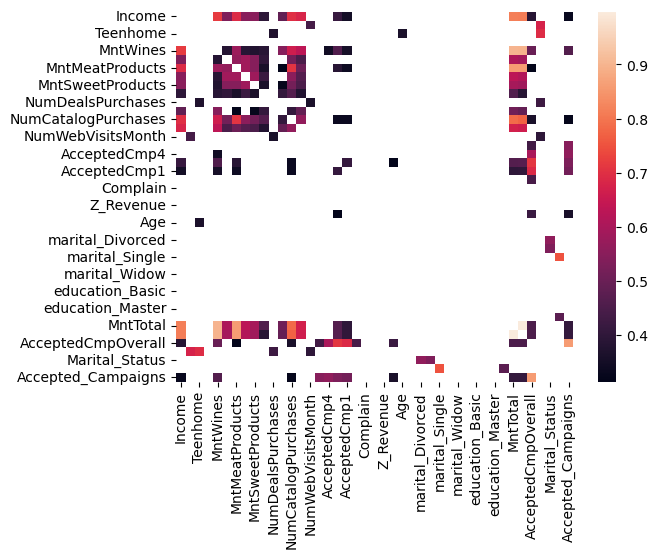

In [58]:
all_correlations = all_correlations[(all_correlations > 0.3) & (all_correlations < 1)]
sns.heatmap(all_correlations)

In [63]:
all_correlations['Accepted_Campaigns']

Income                  0.328398
Kidhome                      NaN
Teenhome                     NaN
Recency                      NaN
MntWines                0.461281
MntFruits                    NaN
MntMeatProducts              NaN
MntFishProducts              NaN
MntSweetProducts             NaN
MntGoldProds                 NaN
NumDealsPurchases            NaN
NumWebPurchases              NaN
NumCatalogPurchases     0.320972
NumStorePurchases            NaN
NumWebVisitsMonth            NaN
AcceptedCmp3            0.546838
AcceptedCmp4            0.561592
AcceptedCmp5            0.531799
AcceptedCmp1            0.514231
AcceptedCmp2                 NaN
Complain                     NaN
Z_CostContact                NaN
Z_Revenue                    NaN
Response                0.360220
Age                          NaN
Customer_Days                NaN
marital_Divorced             NaN
marital_Married              NaN
marital_Single               NaN
marital_Together             NaN
marital_Wi

In [70]:
age_groups = [(23,30),(31,40),(41,50),(51,60),(61,70),(71,85)]
def assign_age_group(Age):
    for age_range in age_groups:
        if age_range[0] <= Age <= age_range[1]:
            return f"{age_range[0]} - {age_range[1]}"
    return('Unknown')
food['age_group'] = food['Age'].apply(assign_age_group)

In [72]:
food[['Age','age_group']].head()

,Age,age_group
0,63,61 - 70
1,66,61 - 70
2,55,51 - 60
3,36,31 - 40
4,39,31 - 40


In [73]:
import seaborn as sns

<Axes: xlabel='age_group', ylabel='Accepted_Campaigns'>

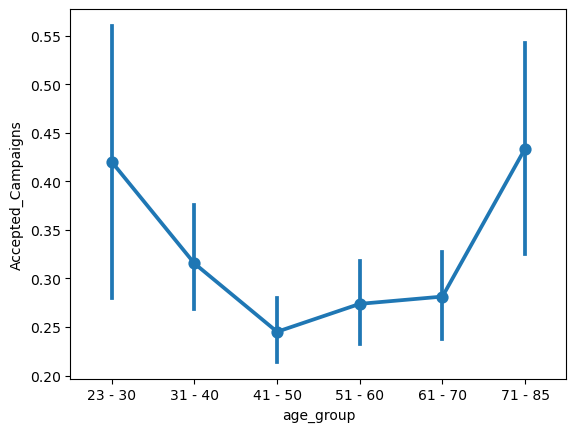

In [76]:
age_order = ['23 - 30','31 - 40','41 - 50','51 - 60','61 - 70','71 - 85']

sns.pointplot(data = food, x = 'age_group', y= 'Accepted_Campaigns', order = age_order)

In [78]:
counts = food['age_group'].value_counts()

In [79]:
percentage = counts/food.shape[0]

In [82]:
percent_food = percentage.reset_index()

In [83]:
percent_food.columns = ['age_group','percentage']

In [86]:
percent_food = percent_food.sort_values('age_group')

In [87]:
percent_food

,age_group,percentage
5,23 - 30,0.027130
3,31 - 40,0.161693
0,41 - 50,0.332067
1,51 - 60,0.221921
2,61 - 70,0.212154
4,71 - 85,0.045035


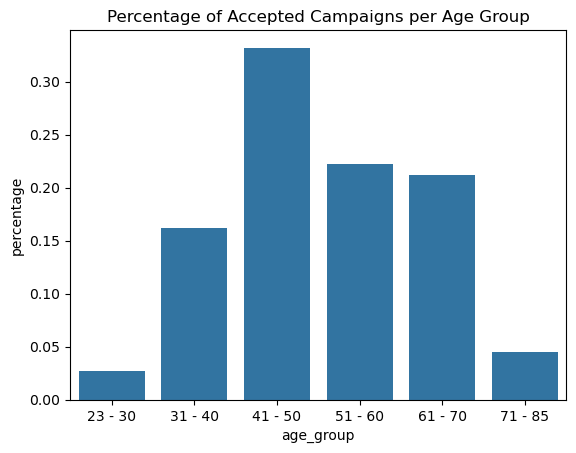

In [89]:
import matplotlib.pyplot as plt
sns.barplot(x='age_group',y='percentage', data=percent_food)
plt.title('Percentage of Accepted Campaigns per Age Group')
plt.show()

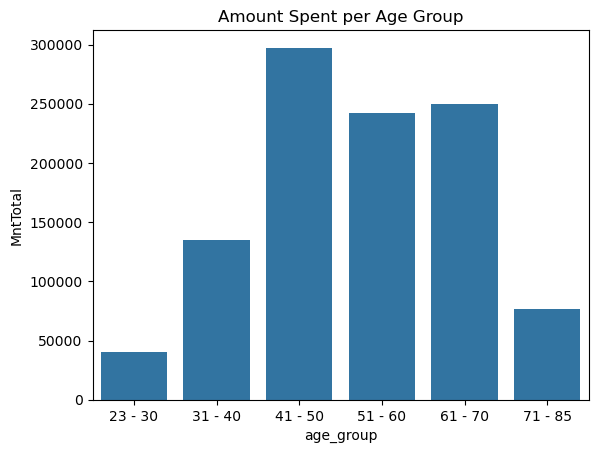

In [96]:
grouped_food = food.groupby('age_group')['MntTotal'].sum().reset_index()

sns.barplot(x = 'age_group', y = 'MntTotal', data = grouped_food)
plt.title('Amount Spent per Age Group')
plt.show()

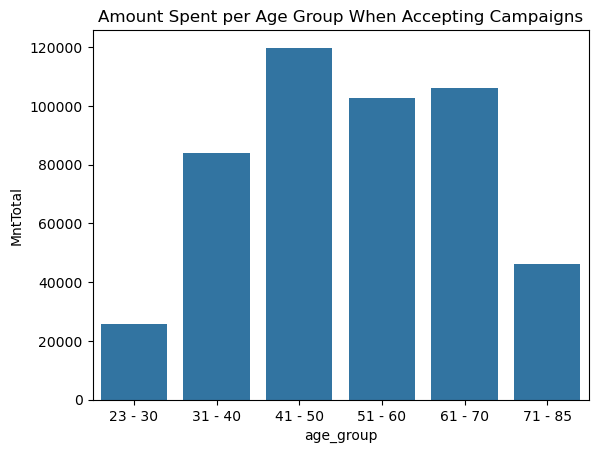

In [99]:
accept_campaign = food[food['Accepted_Campaigns'] != 0]
grouped_food = accept_campaign.groupby('age_group')['MntTotal'].sum().reset_index()

sns.barplot(x = 'age_group', y = 'MntTotal', data = grouped_food)
plt.title('Amount Spent per Age Group When Accepting Campaigns')
plt.show()

In [100]:
# Age Segmentation: Core audience for accepting campaigns is 31-70. ages 23-30, 71 and up accept at higher rates.

In [101]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,Marital_Status,Marital_Status_str,Education_Status,Accepted_Campaigns,age_group
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,3,0,0,1529,1441,0,0,3,Single,6,1,61 - 70
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,3,0,0,21,15,0,2,3,Single,6,0,61 - 70
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,3,0,0,734,692,0,0,2,Together,3,0,51 - 60
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,3,0,0,48,43,0,1,2,Together,3,0,31 - 40
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,5,407,392,0,1,4,married,5,0,31 - 40


In [106]:
sum_food = pd.DataFrame(food[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(), columns = ['Sums'])

In [108]:
sum_food = sum_food.reset_index()

In [109]:
sum_food.rename(columns = {'index':'Type_of_Purchase'}, inplace = True)

In [110]:
sum_food

,Type_of_Purchase,Sums
0,NumWebPurchases,7619
1,NumCatalogPurchases,4871
2,NumStorePurchases,10675


<Axes: xlabel='Type_of_Purchase', ylabel='Sums'>

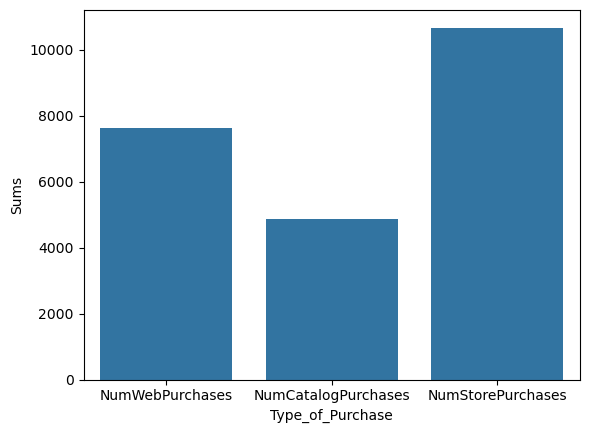

In [111]:
sns.barplot(x = 'Type_of_Purchase', y = 'Sums', data = sum_food)

<Axes: xlabel='Type_of_Purchase', ylabel='Sums'>

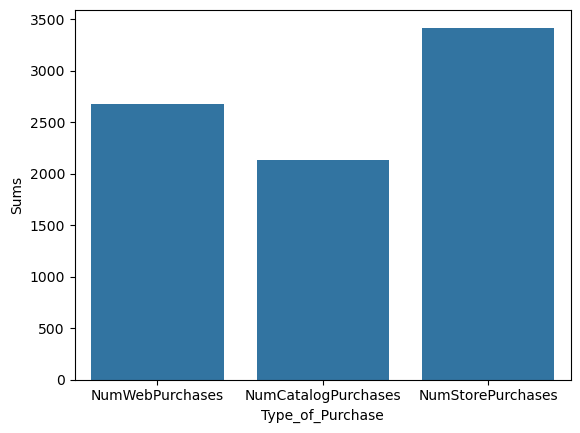

In [112]:
accept_campaign = food[food['Accepted_Campaigns'] != 0]

sum_food = pd.DataFrame(accept_campaign[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(), columns = ['Sums'])
sum_food = sum_food.reset_index()
sum_food.rename(columns = {'index':'Type_of_Purchase'}, inplace = True)
sns.barplot(x = 'Type_of_Purchase', y = 'Sums', data = sum_food)

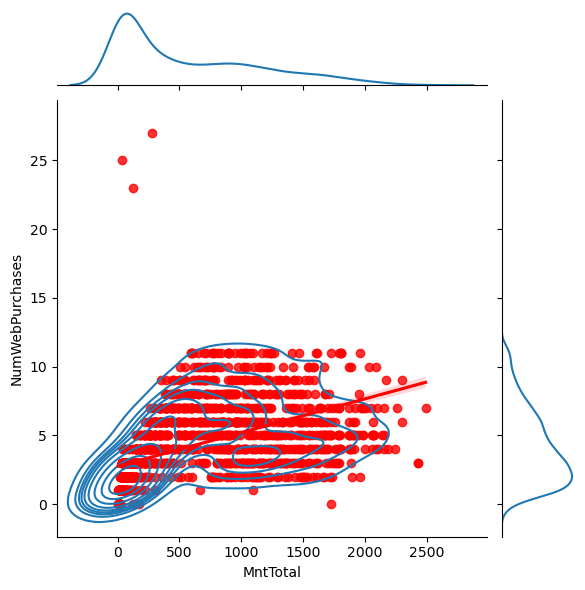

In [116]:
x = sns.jointplot(data = food, x='MntTotal', y= 'NumWebPurchases', kind = 'kde')
x.plot_joint(sns.regplot, color = 'red')

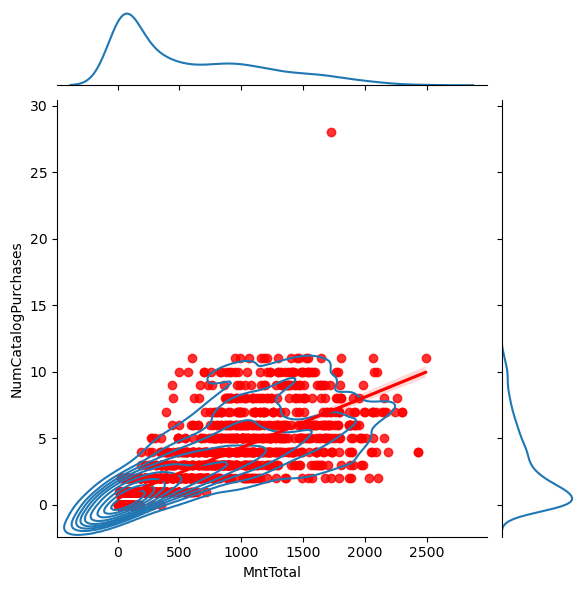

In [117]:
x = sns.jointplot(data = food, x='MntTotal', y= 'NumCatalogPurchases', kind = 'kde')
x.plot_joint(sns.regplot, color = 'red')

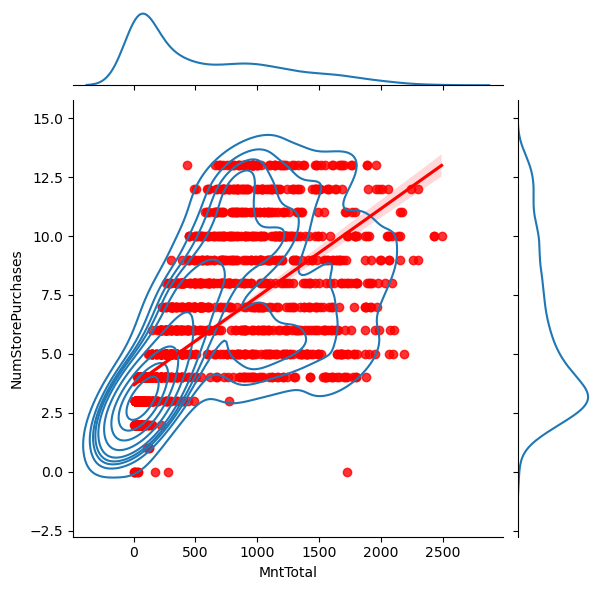

In [118]:
x = sns.jointplot(data = food, x='MntTotal', y= 'NumStorePurchases', kind = 'kde')
x.plot_joint(sns.regplot, color = 'red')

In [ ]:
# 2 directions: bump up the higher percentage catalog customers OR Focus on In Store/Web because they have more traffic.

<Axes: xlabel='Total_Children', ylabel='Accepted_Campaigns'>

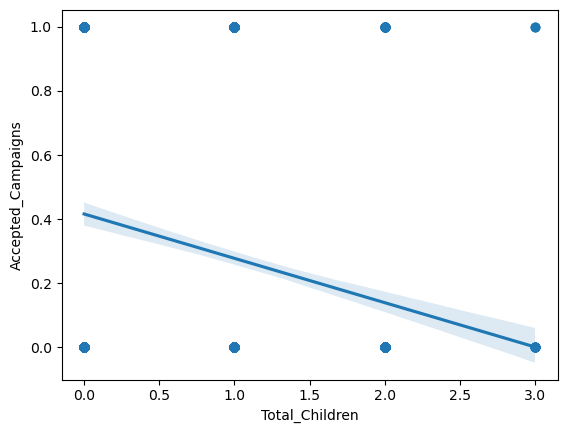

In [120]:
sns.regplot(x = 'Total_Children',y = 'Accepted_Campaigns', data=food)

In [ ]:
# less kids = more likely to spend more money and accept campaigns 

<Axes: xlabel='Education_Status', ylabel='Accepted_Campaigns'>

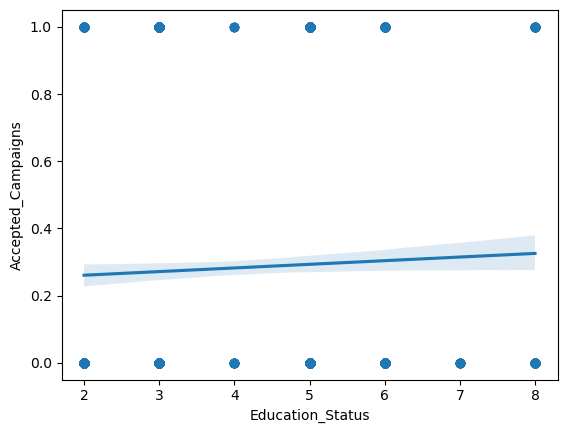

In [121]:
sns.regplot(x = 'Education_Status',y = 'Accepted_Campaigns', data=food)

<Axes: xlabel='Education_Status', ylabel='MntTotal'>

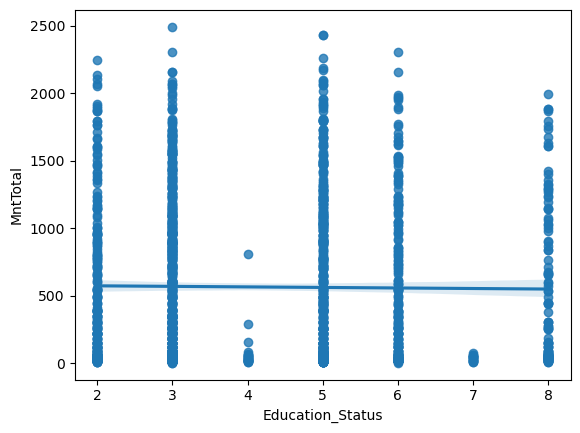

In [122]:
sns.regplot(x = 'Education_Status',y = 'MntTotal', data=food)

In [ ]:
# education seems to have little significence in our segmentation 

<Axes: xlabel='Marital_Status_str', ylabel='count'>

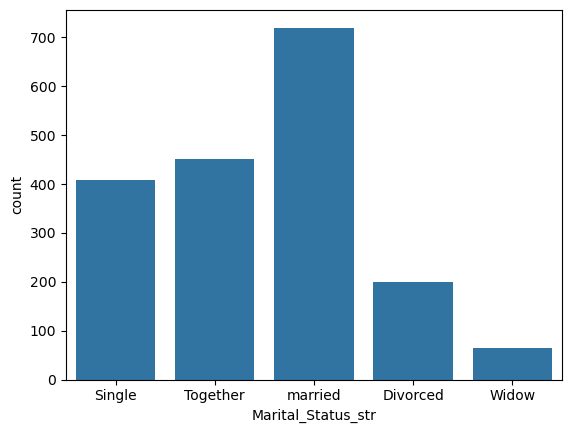

In [123]:
sns.countplot(x = 'Marital_Status_str', data = food)

In [133]:
accept = food[food['Accepted_Campaigns'] != 0]
relationship_food = accept.groupby('Marital_Status_str')['MntTotal'].sum().reset_index()

<Axes: xlabel='Marital_Status_str', ylabel='MntTotal'>

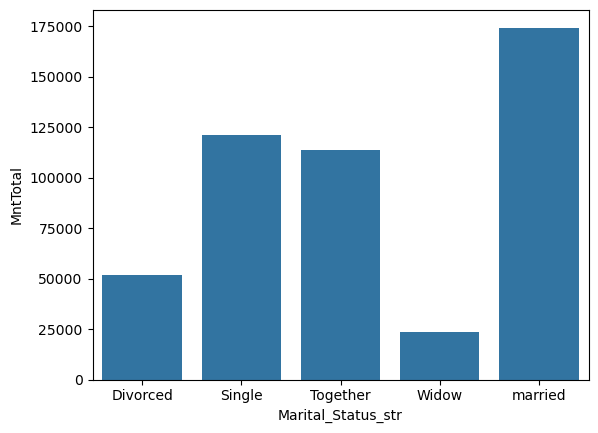

In [134]:
sns.barplot(data = relationship_food, x='Marital_Status_str',y='MntTotal')

In [138]:
total = food['Marital_Status_str'].value_counts()
accepted= food[food['Accepted_Campaigns'] == 1]['Marital_Status_str'].value_counts()

In [139]:
perct_marital = accepted/total * 100

In [142]:
perct_food = perct_marital.reset_index()
perct_food.columns = ['Marital_Status','Percentage']

<Axes: xlabel='Marital_Status', ylabel='Percentage'>

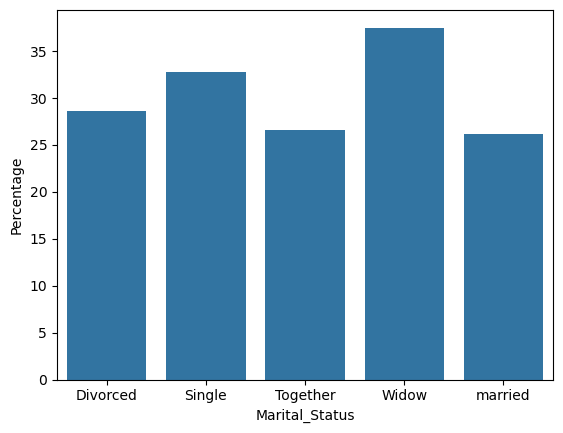

In [143]:
sns.barplot(data = perct_food, x='Marital_Status',y='Percentage')

In [ ]:
# Marital Status: Married, single, together are spending a lot more money than widow and divorced. We should focus More on this segment.